In [19]:
# Import libraries

import sys
import numpy as np
from numpy.typing import ArrayLike
import pandas as pd
from typing import Tuple

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from matplotlib.colors import SymLogNorm

from scipy.optimize import curve_fit, least_squares
from scipy.signal import find_peaks

In [20]:
"""
extract_blocks.py
-----------------
Extracts 5 numpy arrays from a 3-block Keysight CSV file:
    frequency, amp, phase, real, imag

Usage:
    python extract_blocks.py <filename> <lines_per_block>

Example:
    python extract_blocks.py TEST.csv 1001
"""

def extract_blocks(filename: str, lines_per_block: int):
    """
    Parse a CSV file that contains three BEGIN/END data blocks:
      Block 1 : freq, amplitude   (dB)
      Block 2 : freq, phase       (degrees)
      Block 3 : freq, real, imag

    Parameters
    ----------
    filename       : path to the CSV file
    lines_per_block: number of data rows expected in each block

    Returns
    -------
    frequency, amp, phase, real, imag  – five numpy float64 arrays
    """

    blocks = []          # will hold up to 3 lists of raw text lines
    current_block = None

    with open(filename, "r") as fh:
        for line in fh:
            line = line.strip()
            if line == "BEGIN":
                current_block = []
            elif line == "END":
                if current_block is not None:
                    blocks.append(current_block)
                    current_block = None
            elif current_block is not None and line:
                current_block.append(line)

    if len(blocks) != 3:
        raise ValueError(
            f"Expected 3 data blocks delimited by BEGIN/END, found {len(blocks)}."
        )

    def parse_block(block_lines, expected_cols):
        """Convert a list of CSV text lines into a 2-D numpy array."""
        rows = []
        for line in block_lines:
            parts = line.split(",")
            if len(parts) < expected_cols:
                continue                  # skip malformed rows silently
            rows.append([float(p) for p in parts[:expected_cols]])
        arr = np.array(rows, dtype=np.float64)
        if len(arr) != lines_per_block:
            print(
                f"  Warning: block has {len(arr)} rows, expected {lines_per_block}.",
                file=sys.stderr,
            )
        return arr

    block1 = parse_block(blocks[0], 2)   # freq, amp
    block2 = parse_block(blocks[1], 2)   # freq, phase
    block3 = parse_block(blocks[2], 3)   # freq, real, imag

    frequency = block1[:, 0]
    amp       = block1[:, 1]
    phase     = block2[:, 1]
    real      = block3[:, 1]
    imag      = block3[:, 2]

    return frequency, amp, phase, real, imag

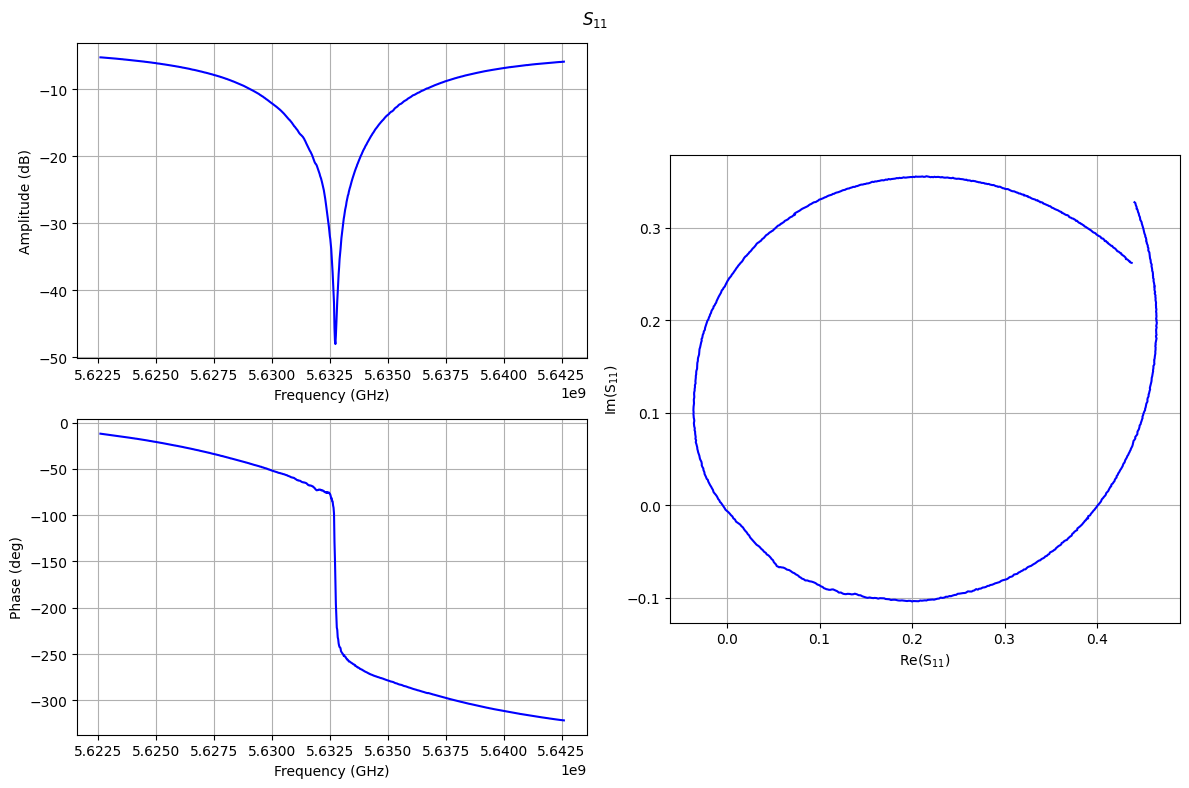

In [22]:
filepath = 'Data_Old_Cavity/TEST.csv'

freq, amp_dB, phase_deg, real, imag = extract_blocks(filepath, 1001)

plot_data_S11(filepath = None,
                  freq = freq,
                  amp_dB = amp_dB,
                  phase_deg = phase_deg,
                  real = real,
                  imag = imag)